# Bias-Variance Tradeoff
### The Fundamental Tradeoff in Machine Learning

**Total Error = Bias² + Variance + Irreducible Error**
- Bias: Error from wrong assumptions
- Variance: Error from sensitivity to training data
- Goal: Minimize both!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. The Dartboard Analogy
**Classic visualization of bias and variance**

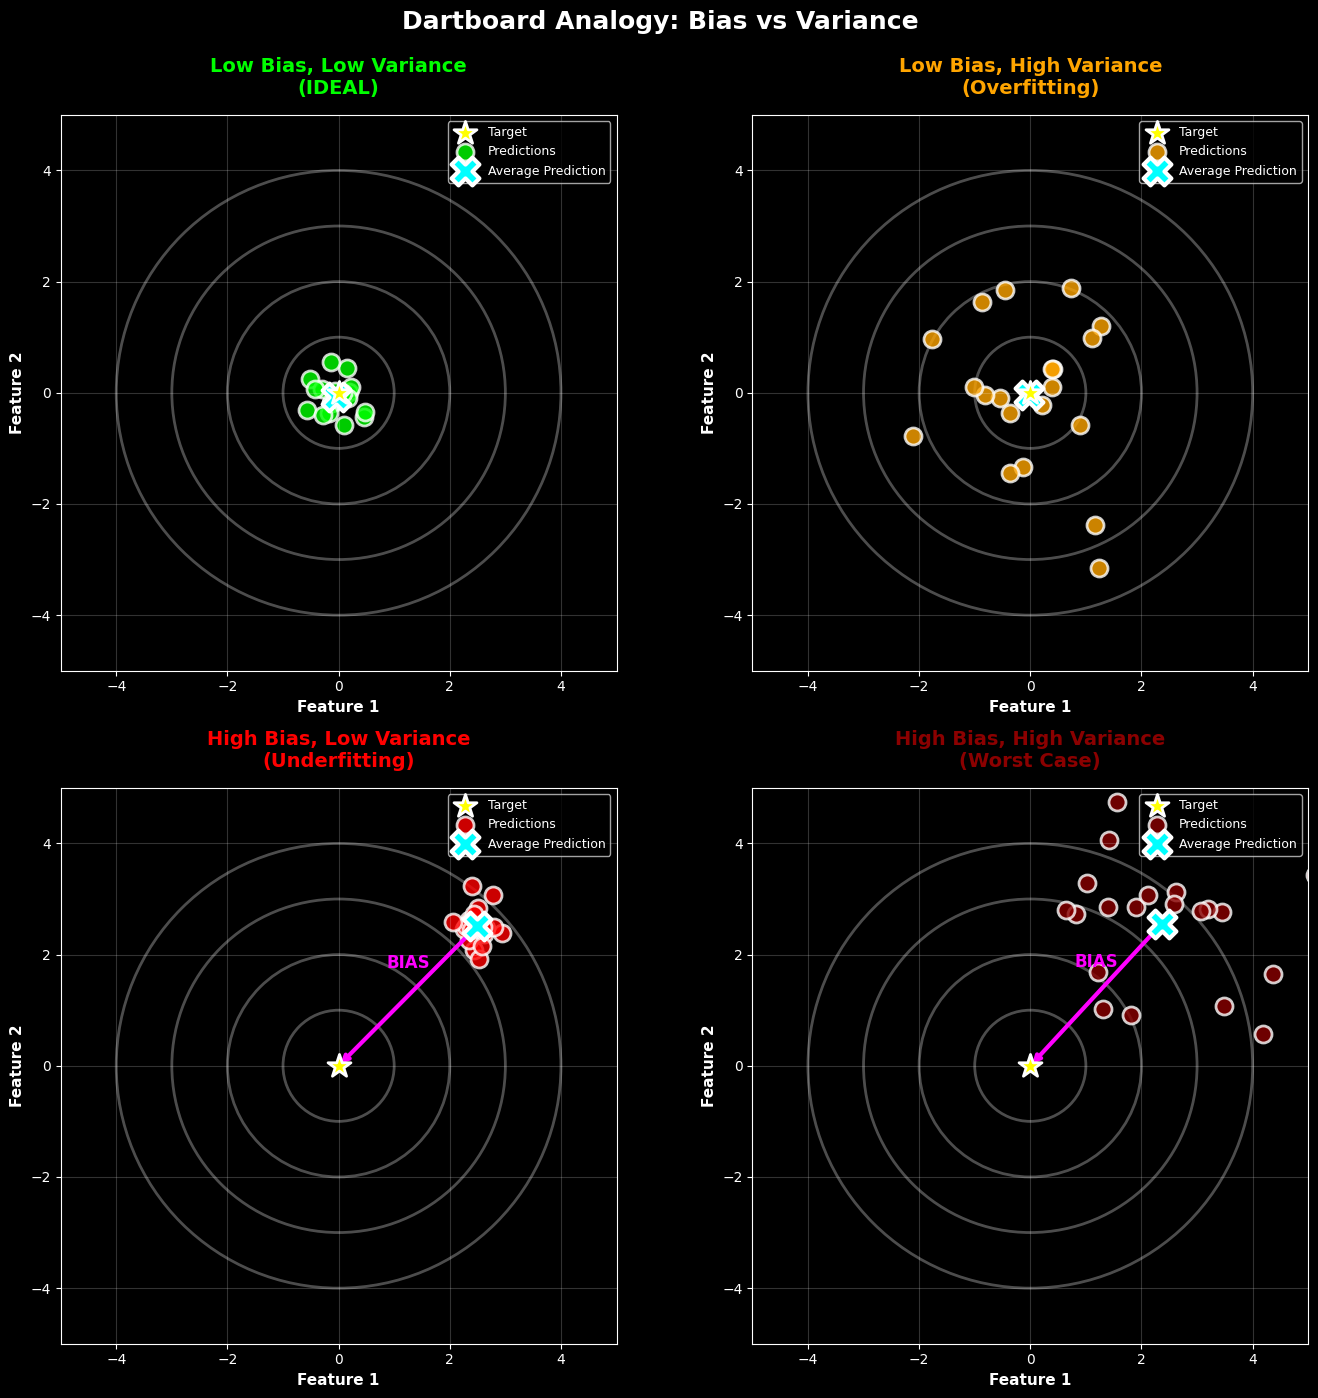

Dartboard Interpretation:
Bullseye (yellow star) = True target
Darts (colored dots) = Individual predictions
Cyan X = Average prediction

BIAS = Distance from average prediction to target
VARIANCE = Spread of predictions around average

IDEAL: Tight cluster around bullseye (low bias, low variance)


In [2]:
# Create dartboard visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

scenarios = [
    {'bias': 'low', 'variance': 'low', 'title': 'Low Bias, Low Variance\n(IDEAL)', 'color': 'lime'},
    {'bias': 'low', 'variance': 'high', 'title': 'Low Bias, High Variance\n(Overfitting)', 'color': 'orange'},
    {'bias': 'high', 'variance': 'low', 'title': 'High Bias, Low Variance\n(Underfitting)', 'color': 'red'},
    {'bias': 'high', 'variance': 'high', 'title': 'High Bias, High Variance\n(Worst Case)', 'color': 'darkred'}
]

for ax, scenario in zip(axes.flat, scenarios):
    # Draw dartboard circles
    for radius in [1, 2, 3, 4]:
        circle = Circle((0, 0), radius, fill=False, edgecolor='white', 
                       linewidth=2, alpha=0.3)
        ax.add_patch(circle)
    
    # Draw center (bullseye)
    ax.scatter(0, 0, s=300, c='yellow', marker='*', 
              edgecolors='white', linewidth=2, zorder=5, label='Target')
    
    # Generate dart throws based on bias and variance
    n_darts = 20
    
    if scenario['bias'] == 'low':
        center_x, center_y = 0, 0  # Centered on target
    else:
        center_x, center_y = 2.5, 2.5  # Off-center
    
    if scenario['variance'] == 'low':
        spread = 0.3  # Tight cluster
    else:
        spread = 1.2  # Scattered
    
    # Generate dart positions
    darts_x = np.random.normal(center_x, spread, n_darts)
    darts_y = np.random.normal(center_y, spread, n_darts)
    
    # Plot darts
    ax.scatter(darts_x, darts_y, s=150, c=scenario['color'], 
              edgecolors='white', linewidth=2, alpha=0.8, label='Predictions')
    
    # Draw mean prediction
    mean_x, mean_y = np.mean(darts_x), np.mean(darts_y)
    ax.scatter(mean_x, mean_y, s=400, c='cyan', marker='X', 
              edgecolors='white', linewidth=3, zorder=4, label='Average Prediction')
    
    # Draw bias arrow (from target to average)
    if scenario['bias'] == 'high':
        ax.annotate('', xy=(mean_x, mean_y), xytext=(0, 0),
                   arrowprops=dict(arrowstyle='<->', color='magenta', lw=3))
        ax.text(mean_x/2, mean_y/2 + 0.5, 'BIAS', fontsize=12, 
               fontweight='bold', color='magenta', ha='center')
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(scenario['title'], fontsize=14, fontweight='bold', 
                color=scenario['color'], pad=15)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.2)
    ax.set_xlabel('Feature 1', fontsize=11, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=11, fontweight='bold')

plt.suptitle('Dartboard Analogy: Bias vs Variance', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Dartboard Interpretation:")
print("="*60)
print("Bullseye (yellow star) = True target")
print("Darts (colored dots) = Individual predictions")
print("Cyan X = Average prediction\n")
print("BIAS = Distance from average prediction to target")
print("VARIANCE = Spread of predictions around average\n")
print("IDEAL: Tight cluster around bullseye (low bias, low variance)")
print("="*60)

## 2. Mathematical Decomposition
**Error = Bias² + Variance + Noise**

In [3]:
# Simulate bias and variance for different model complexities
model_complexity = np.linspace(1, 20, 50)

# Bias decreases with complexity (exponential decay)
bias_squared = 5 * np.exp(-0.3 * model_complexity) + 0.1

# Variance increases with complexity (exponential growth)
variance = 0.05 + 0.01 * (model_complexity ** 1.5)

# Irreducible error (constant)
irreducible_error = np.ones_like(model_complexity) * 0.5

# Total error
total_error = bias_squared + variance + irreducible_error

# Find optimal complexity
optimal_idx = np.argmin(total_error)
optimal_complexity = model_complexity[optimal_idx]

print(f"Optimal Model Complexity: {optimal_complexity:.2f}")
print(f"Minimum Total Error: {total_error[optimal_idx]:.3f}")
print(f"  - Bias² at optimal: {bias_squared[optimal_idx]:.3f}")
print(f"  - Variance at optimal: {variance[optimal_idx]:.3f}")
print(f"  - Irreducible error: {irreducible_error[optimal_idx]:.3f}")

Optimal Model Complexity: 11.47
Minimum Total Error: 1.199
  - Bias² at optimal: 0.260
  - Variance at optimal: 0.438
  - Irreducible error: 0.500


## 3. The Tradeoff Curve
**The classic U-shaped total error**

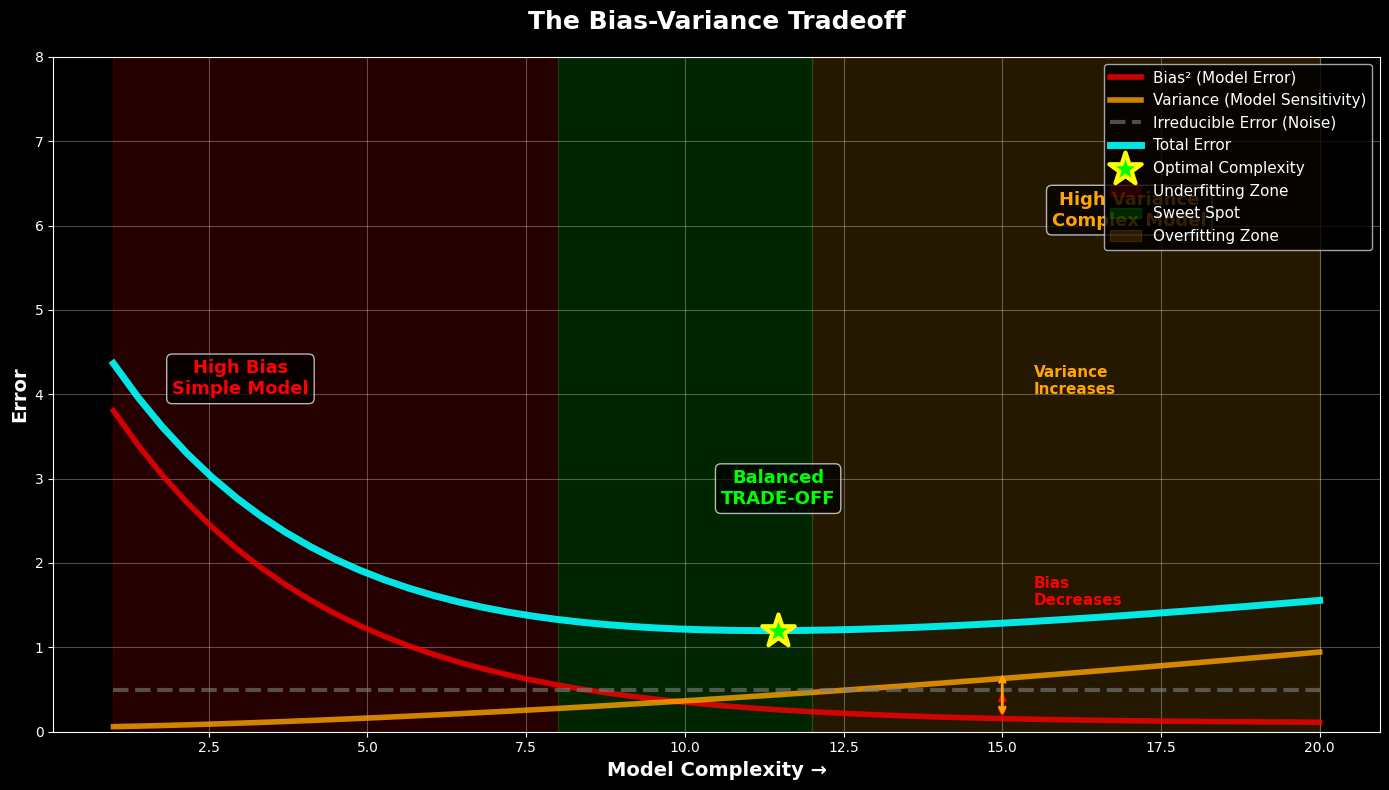


Key Insights:
As Model Complexity INCREASES:
  - Bias DECREASES (better fit to training data)
  - Variance INCREASES (more sensitive to data)

Optimal Model: Minimizes TOTAL error (bias² + variance)

U-shaped curve: Too simple OR too complex = HIGH error!


In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

# Plot individual components
ax.plot(model_complexity, bias_squared, 'red', linewidth=4, 
       label='Bias² (Model Error)', alpha=0.8)
ax.plot(model_complexity, variance, 'orange', linewidth=4, 
       label='Variance (Model Sensitivity)', alpha=0.8)
ax.plot(model_complexity, irreducible_error, 'gray', linewidth=3, 
       linestyle='--', label='Irreducible Error (Noise)', alpha=0.6)

# Plot total error
ax.plot(model_complexity, total_error, 'cyan', linewidth=5, 
       label='Total Error', alpha=0.9)

# Mark optimal point
ax.scatter(optimal_complexity, total_error[optimal_idx], 
          s=600, c='lime', marker='*', edgecolors='yellow', 
          linewidth=3, zorder=5, label='Optimal Complexity')

# Shade regions
ax.axvspan(1, 8, alpha=0.15, color='red', label='Underfitting Zone')
ax.axvspan(8, 12, alpha=0.15, color='lime', label='Sweet Spot')
ax.axvspan(12, 20, alpha=0.15, color='orange', label='Overfitting Zone')

# Add annotations
ax.annotate('High Bias\nSimple Model', xy=(3, 4), fontsize=13, 
           fontweight='bold', color='red', ha='center',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

ax.annotate('Balanced\nTRADE-OFF', xy=(optimal_complexity, total_error[optimal_idx] + 1.5), 
           fontsize=13, fontweight='bold', color='lime', ha='center',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7),
           arrowprops=dict(arrowstyle='->', color='lime', lw=2))

ax.annotate('High Variance\nComplex Model', xy=(17, 6), fontsize=13, 
           fontweight='bold', color='orange', ha='center',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Arrow showing tradeoff
ax.annotate('', xy=(15, bias_squared[40]), xytext=(15, 0.5),
           arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(15.5, 1.5, 'Bias\nDecreases', fontsize=11, color='red', fontweight='bold')

ax.annotate('', xy=(15, variance[10]), xytext=(15, variance[40]),
           arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
ax.text(15.5, 4, 'Variance\nIncreases', fontsize=11, color='orange', fontweight='bold')

ax.set_xlabel('Model Complexity →', fontsize=14, fontweight='bold')
ax.set_ylabel('Error', fontsize=14, fontweight='bold')
ax.set_title('The Bias-Variance Tradeoff', fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_ylim([0, 8])

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("="*60)
print("As Model Complexity INCREASES:")
print("  - Bias DECREASES (better fit to training data)")
print("  - Variance INCREASES (more sensitive to data)")
print("\nOptimal Model: Minimizes TOTAL error (bias² + variance)")
print("\nU-shaped curve: Too simple OR too complex = HIGH error!")
print("="*60)

## 4. Visual Summary
**Quick reference comparison**

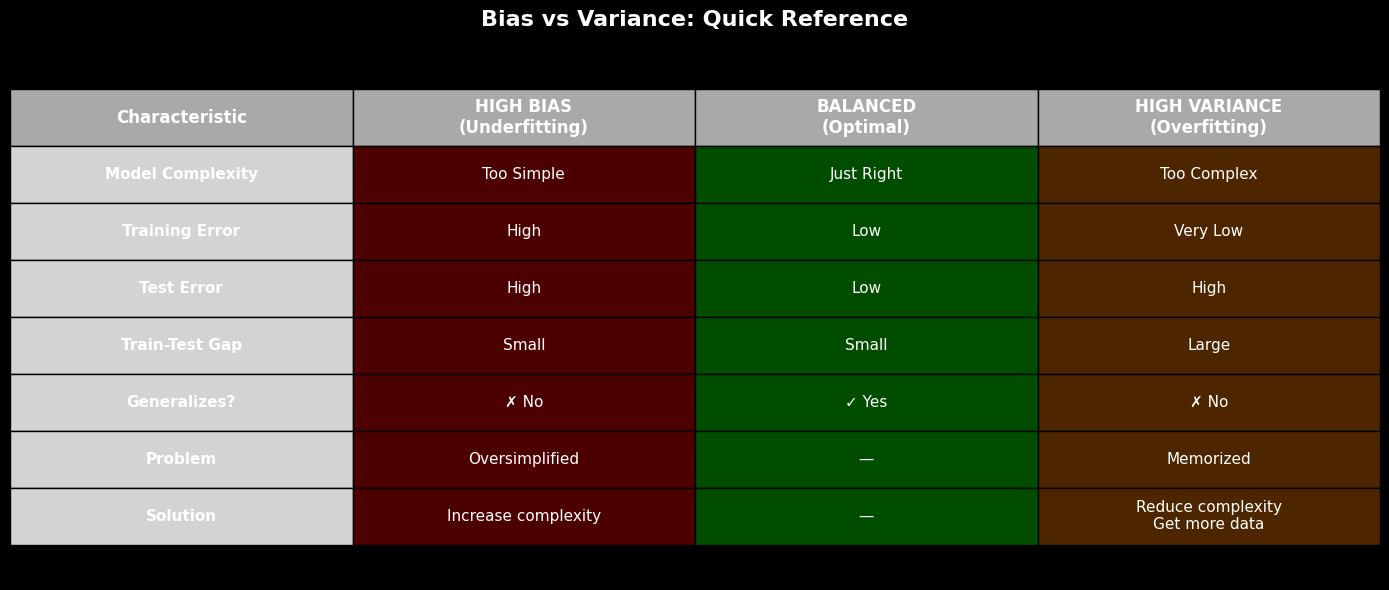

In [5]:
# Create comparison table
fig, ax = plt.subplots(figsize=(14, 6))

# Hide axes
ax.axis('off')

# Table data
table_data = [
    ['Characteristic', 'HIGH BIAS\n(Underfitting)', 'BALANCED\n(Optimal)', 'HIGH VARIANCE\n(Overfitting)'],
    ['Model Complexity', 'Too Simple', 'Just Right', 'Too Complex'],
    ['Training Error', 'High', 'Low', 'Very Low'],
    ['Test Error', 'High', 'Low', 'High'],
    ['Train-Test Gap', 'Small', 'Small', 'Large'],
    ['Generalizes?', '✗ No', '✓ Yes', '✗ No'],
    ['Problem', 'Oversimplified', '—', 'Memorized'],
    ['Solution', 'Increase complexity', '—', 'Reduce complexity\nGet more data'],
]

colors = [['white', 'red', 'lime', 'orange']] + \
         [['lightgray', '#4d0000', '#004d00', '#4d2600']] * (len(table_data) - 1)

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                cellColours=colors, colWidths=[0.25, 0.25, 0.25, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style header row
for i in range(4):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', size=12)
    cell.set_facecolor('darkgray')

# Style first column
for i in range(len(table_data)):
    cell = table[(i, 0)]
    cell.set_text_props(weight='bold')

plt.title('Bias vs Variance: Quick Reference', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Key Takeaways

### The Fundamental Equation:
**Expected Test Error = Bias² + Variance + Irreducible Error**

### Definitions:

**Bias (Systematic Error):**
- Error from wrong assumptions in the model
- High bias = Model too simple (underfitting)
- Can't capture underlying pattern
- Training error is high

**Variance (Random Error):**
- Error from sensitivity to training data
- High variance = Model too complex (overfitting)
- Captures noise as if it's pattern
- Training error is low, test error is high

**Irreducible Error:**
- Inherent noise in data
- Cannot be reduced by any model
- Lower bound on achievable error

### The Tradeoff:
- **Decrease bias** → Usually increases variance
- **Decrease variance** → Usually increases bias
- **Goal:** Find sweet spot that minimizes total error

### How to Balance:

**Reduce Bias:**
- Use more complex model
- Add more features
- Train longer
- Reduce regularization

**Reduce Variance:**
- Get more training data (best!)
- Simplify model
- Use regularization (L1/L2)
- Ensemble methods (bagging)
- Cross-validation
- Dropout

### Diagnostic:
- **High training error** → High bias (underfit)
- **Large train-test gap** → High variance (overfit)
- **Both low** → Optimal! ✓

### Remember:
**You can't eliminate both bias and variance completely!**

The art of ML = Managing this tradeoff! 🎯